### Bài 3: Xây dựng kiến trúc Encoder trong đó Encoder gồm 5 lớp BiLSTM với hidden size là 256 cho bài toán nhận diện thực thể (Name Entity Recognition). Huấn luyện mô hình trên bộ dữ liệu PhoNER và đánh giá độ hiệu quả của mô hình sử dụng độ đo F1.

In [1]:
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q seqeval

In [3]:
import numpy as np

# 1. Đọc dữ liệu

In [4]:
def load_conll(file_path):
    """
    Đọc file .conll và trả về list các câu và list các nhãn tương ứng.
    """
    sentences = []
    tags = []

    current_sent = []
    current_tags = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # Gặp dòng trắng (hoặc hết file) nghĩa là kết thúc 1 câu
            if not line:
                if len(current_sent) > 0:
                    sentences.append(current_sent)
                    tags.append(current_tags)
                    current_sent = []
                    current_tags = []
            else:
                # Tách từ và nhãn (cách nhau bởi space)
                parts = line.split()
                # "Bác_sĩ O" -> len=2

                if len(parts) >= 2:
                    word = parts[0]
                    tag = parts[-1] # Lấy phần tử cuối cùng làm tag

                    current_sent.append(word)
                    current_tags.append(tag)

    # Thêm câu cuối cùng nếu file không kết thúc bằng dòng trắng
    if len(current_sent) > 0:
        sentences.append(current_sent)
        tags.append(current_tags)

    return sentences, tags

In [5]:
# Đường dẫn thư mục dữ liệu trên Drive
data_dir = "/content/drive/MyDrive/MonHocTrenTruong/DS201/Lab-thuc-hanh/Lab-3/Bai3_data"

# Đường dẫn đến các file conll
train_file = os.path.join(data_dir, "train_word.conll")
dev_file   = os.path.join(data_dir, "dev_word.conll")
test_file  = os.path.join(data_dir, "test_word.conll")

# Load dữ liệu
train_sents, train_tags = load_conll(train_file)
dev_sents, dev_tags     = load_conll(dev_file)
test_sents, test_tags    = load_conll(test_file)

print(f"Số lượng câu train: {len(train_sents)}")
print(f"Câu train đầu tiên: {train_sents[0]}")
print(f"Số lượng unique nhãn train: {len(set(tag for tags in train_tags for tag in tags))}")

Số lượng câu train: 5027
Câu train đầu tiên: ['Đồng_thời', ',', 'bệnh_viện', 'tiếp_tục', 'thực_hiện', 'các', 'biện_pháp', 'phòng_chống', 'dịch_bệnh', 'COVID', '-', '19', 'theo', 'hướng_dẫn', 'của', 'Bộ', 'Y_tế', '.']
Số lượng unique nhãn train: 20


# 2. Mã hóa dữ liệu (Tokenization & Encoding)

## 2.1 Chọn các siêu tham số - Dựa trên phân tích EDA

In [6]:
MAX_LEN = 126
NUM_CLASSES = 21

## 2.2 Xây dựng các hàm xử lý thủ công - Tạo tập từ điển + encoding

In [7]:
def create_vocab(sentences):
    """Tạo bộ từ điển từ danh sách các câu (list of lists)"""
    vocab_set = set()
    for sent in sentences:
        vocab_set.update(sent)
    return sorted(list(vocab_set))

def create_mappings(vocab_list, all_tags_list):
    """Tạo mapping từ chữ/nhãn sang số"""
    # word2idx: 0 cho Padding, 1 cho Unknown
    word2idx = {'<PAD>': 0, '<UNK>': 1}
    for idx, word in enumerate(vocab_list, start=2):
        word2idx[word] = idx

    # tag2idx: Chỉ map các nhãn thực tế
    unique_tags = sorted(list(set(tag for tags in all_tags_list for tag in tags)))
    tag2idx = {tag: idx for idx, tag in enumerate(unique_tags)}

    return word2idx, tag2idx

In [8]:
vocab_list = create_vocab(train_sents)
word2idx, tag2idx = create_mappings(vocab_list, train_tags)

print(f"Kích thước tập từ vựng (Vocab size): {len(word2idx)}")
print(f"Danh sách nhãn và ID tương ứng:\n{tag2idx}")

Kích thước tập từ vựng (Vocab size): 5243
Danh sách nhãn và ID tương ứng:
{'B-AGE': 0, 'B-DATE': 1, 'B-GENDER': 2, 'B-JOB': 3, 'B-LOCATION': 4, 'B-NAME': 5, 'B-ORGANIZATION': 6, 'B-PATIENT_ID': 7, 'B-SYMPTOM_AND_DISEASE': 8, 'B-TRANSPORTATION': 9, 'I-AGE': 10, 'I-DATE': 11, 'I-JOB': 12, 'I-LOCATION': 13, 'I-NAME': 14, 'I-ORGANIZATION': 15, 'I-PATIENT_ID': 16, 'I-SYMPTOM_AND_DISEASE': 17, 'I-TRANSPORTATION': 18, 'O': 19}


In [9]:
def encode_and_pad(data_sents, data_tags, word2idx, tag2idx, max_len):
    """Chuyển câu và nhãn thành dãy số và padding"""
    encoded_sents = []
    encoded_tags = []

    for sent, tags in zip(data_sents, data_tags):
        # 1. Encode Sentence
        sent_seq = [word2idx.get(word, word2idx['<UNK>']) for word in sent]

        # 2. Encode Tags
        tag_seq = [tag2idx.get(tag) for tag in tags]

        # 3. Padding/Truncating
        if len(sent_seq) < max_len:
            # Padding: Thêm 0 cho câu, thêm -100 cho nhãn
            sent_seq = sent_seq + [word2idx['<PAD>']] * (max_len - len(sent_seq))
            tag_seq = tag_seq + [-100] * (max_len - len(tag_seq))
        else:
            # Truncating: Cắt bớt nếu dài quá max_len
            sent_seq = sent_seq[:max_len]
            tag_seq = tag_seq[:max_len]

        encoded_sents.append(sent_seq)
        encoded_tags.append(tag_seq)

    return np.array(encoded_sents), np.array(encoded_tags)

In [10]:
# Thực thi mã hóa cho cả 3 tập
train_ids, train_tag_ids = encode_and_pad(train_sents, train_tags, word2idx, tag2idx, MAX_LEN)
dev_ids, dev_tag_ids = encode_and_pad(dev_sents, dev_tags, word2idx, tag2idx, MAX_LEN)
test_ids, test_tag_ids = encode_and_pad(test_sents, test_tags, word2idx, tag2idx, MAX_LEN)

print(f"Shape tập train: {train_ids.shape}")
print(f"Shape nhãn train: {train_tag_ids.shape}")
print("Câu đầu tiên:", train_ids[0][:20])
print("Câu đầu tiên:", train_tag_ids[0][:20])

Shape tập train: (5027, 126)
Shape nhãn train: (5027, 126)
Câu đầu tiên: [5019   10 2783 4457 4421 2999 2687 4037 3186 1283   11  265 4296 3383
 3104 1267 2644   12    0    0]
Câu đầu tiên: [  19   19   19   19   19   19   19   19   19   19   19   19   19   19
   19    6   15   19 -100 -100]


> Câu thứ 1 trong bộ train:
>
>Đồng_thời, bệnh_viện tiếp_tục thực_hiện các biện_pháp phòng_chống dịch_bệnh COVID-19 theo hướng_dẫn của Bộ Y_tế.

- 19 là đại diện cho nhãn `O - Outside`
- `-100 là padding 0` do trong PyTorch, hàm mất mát nn.CrossEntropyLoss có một tham số mặc định là ignore_index=-100, khi tính loss thì sẽ bỏ qua các vị trí có nhãn là -100.

## 2.3 Tạo attention_mask

In [11]:
def create_attention_mask(input_ids, pad_idx=0):
    return (input_ids != pad_idx).astype(int)

In [12]:
train_mask = create_attention_mask(train_ids)
dev_mask   = create_attention_mask(dev_ids)
test_mask  = create_attention_mask(test_ids)

In [13]:
print(train_mask.shape) # 126 mà max_len đã set

(5027, 126)


# 3. Chuẩn bị dữ liệu cho huấn luyện (Dataset & DataLoader)

## 3.1 Định nghĩa NERDataset

In [14]:
import torch
from torch.utils.data import Dataset

class NERDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

## 3.2 Tạo Dataset cho train / dev / test

In [15]:
train_dataset = NERDataset(train_ids, train_mask, train_tag_ids)
dev_dataset   = NERDataset(dev_ids,   dev_mask,   dev_tag_ids)
test_dataset  = NERDataset(test_ids,  test_mask,  test_tag_ids)

print(len(train_dataset), len(dev_dataset), len(test_dataset))

5027 2000 3000


## 3.3 Tạo DataLoader

In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


## 3.4 Sanity check

In [17]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)      # [B, L]
print(batch["attention_mask"].shape) # [B, L]
print(batch["labels"].shape)         # [B, L]

# torch.Size([32, 126])
# torch.Size([32, 126])
# torch.Size([32, 126])

torch.Size([32, 126])
torch.Size([32, 126])
torch.Size([32, 126])


# 4. Positional Encoding (Sin–Cos theo Attention Is All You Need)

## 4.1 Class PositionalEncoding (sin–cos)

In [18]:
import torch
import torch.nn as nn
import math
from torch import Tensor

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()

        # Tạo ma trận positional encoding [max_len, d_model]
        pe = torch.zeros(max_len, d_model)

        # Vector vị trí [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len).unsqueeze(1) # Biến đổi shape thành [max_len, 1] để sau nhân với div_term ra shape [max_len, d_model/2]

        # Vector tần số cách thông thường:
        div_term = 1 / (10000 ** (torch.arange(0, d_model, 2) / d_model))

        # Áp dụng sin cho chiều chẵn
        pe[:, 0::2] = torch.sin(position * div_term)

        # Áp dụng cos cho chiều lẻ
        pe[:, 1::2] = torch.cos(position * div_term)

        # Đưa về shape [1, max_len, d_model] để broadcast theo batch
        pe = pe.unsqueeze(0)

        # Register buffer: không train, nhưng đi theo model
        # pe không phải tham số cần học nên không backprop nhưng nó phải trong model để khi save/load model thì pe cũng được lưu theo
        self.register_buffer("pe", pe)

    def forward(self, x: Tensor) -> Tensor:
        """
        x: Tensor shape [batch_size, seq_len, d_model]
        """
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :] # Cộng trực tiếp kiểu element-wise chứ không phải concat

## 4.2. Token Embedding + Positional Encoding

In [19]:
class EmbeddingLayer(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, max_len: int) -> None:
        super().__init__()

        # Embedding ánh xạ token id sang vector embedding
        self.token_embedding = nn.Embedding(vocab_size, d_model)

        # Positional Encoding - Không được train
        self.positional_encoding = PositionalEncoding(d_model, max_len)

    def forward(self, input_ids: Tensor) -> Tensor:
        """
        input_ids: [batch_size, seq_len]
        """
        x = self.token_embedding(input_ids)
        x = self.positional_encoding(x)
        return x

## 4.3. Sanity check Embedding + Positional Encoding

In [20]:
# Kiểm tra chiều

embedding_layer = EmbeddingLayer(
    vocab_size=len(word2idx),
    d_model=256,
    max_len=MAX_LEN
)

batch = next(iter(train_loader))
input_ids = batch["input_ids"]   # [B, L]

embeddings = embedding_layer(input_ids)

print("Input IDs shape:", input_ids.shape)
print("Embedding output shape:", embeddings.shape)

Input IDs shape: torch.Size([32, 126])
Embedding output shape: torch.Size([32, 126, 256])


In [21]:
# kiểm tra Positional Encoding có được cộng không

# Lấy embedding của cùng 1 token ở 2 vị trí khác nhau
token_pos_1 = embeddings[0, 0]   # token đầu tiên
token_pos_2 = embeddings[0, 1]   # token thứ hai

diff = torch.norm(token_pos_1 - token_pos_2)

print("L2 distance between position 0 and 1:", diff.item())

L2 distance between position 0 and 1: 24.124557495117188


# 5. Transformer Encoder (3 layers)

## 5.1 Định nghĩa class MultiHeadSelfAttention

In [22]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int) -> None:
        """
        Args:
            d_model (int): kích thước embedding (vd: 256, 512)
            num_heads (int): số head attention (vd: 8)
        """
        super().__init__()

        # Điều kiện bắt buộc:
        # d_model phải chia hết cho num_heads
        assert d_model % num_heads == 0

        self.d_model: int = d_model
        self.num_heads: int = num_heads

        # Kích thước embedding của MỖI head
        # Ví dụ: d_model=256, num_heads=8 -> head_dim=32
        self.head_dim: int = d_model // num_heads

        # Linear chiếu từ x -> [Q | K | V]
        # Input : [B, L, d_model]
        # Output: [B, L, 3 * d_model]
        self.qkv_proj: nn.Linear = nn.Linear(d_model, 3 * d_model)

        # Linear cuối để gộp các head lại
        self.out_proj: nn.Linear = nn.Linear(d_model, d_model)

    def forward(self, x: Tensor, attention_mask: Tensor) -> Tensor:
        """
        Args:
            x (Tensor):
                shape [batch_size, seq_len, d_model]
                embedding đầu vào (đã cộng positional encoding)

            attention_mask (Tensor):
                shape [batch_size, seq_len]
                1 = token thật
                0 = padding token (không được attend)

        Returns:
            Tensor:
                shape [batch_size, seq_len, d_model]
        """

        # -------------------------
        # 1. Lấy kích thước cơ bản
        # -------------------------
        B, L, _ = x.size()   # B=batch_size, L=seq_len

        # -------------------------
        # 2. Tạo Q, K, V
        # -------------------------

        # Chiếu x thành QKV gộp
        # [B, L, d_model] -> [B, L, 3*d_model]
        qkv: Tensor = self.qkv_proj(x)

        # Tách Q, K, V và chia head
        # [B, L, 3*d_model]
        # -> [B, L, 3, num_heads, head_dim]
        qkv = qkv.reshape(B, L, 3, self.num_heads, self.head_dim)

        # Đổi trục để tiện tính attention
        # [B, L, 3, H, D]
        # -> [3, B, H, L, D]
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # Tách riêng từng tensor
        Q: Tensor = qkv[0]   # [B, H, L, D]
        K: Tensor = qkv[1]   # [B, H, L, D]
        V: Tensor = qkv[2]   # [B, H, L, D]

        # -------------------------
        # 3. Tính attention score
        # -------------------------

        # Q @ K^T
        # [B, H, L, D] @ [B, H, D, L]
        # -> [B, H, L, L]
        scores: Tensor = torch.matmul(Q, K.transpose(-2, -1))

        # Scaling để tránh gradient quá lớn
        scores = scores / math.sqrt(self.head_dim)

        # -------------------------
        # 4. Mask padding token
        # -------------------------

        # attention_mask: [B, L]
        # -> [B, 1, 1, L] để broadcast cho mọi head & query
        attention_mask = attention_mask.unsqueeze(1).unsqueeze(2)

        # Gán -inf cho các vị trí padding
        scores = scores.masked_fill(attention_mask == 0, float("-inf"))

        # -------------------------
        # 5. Softmax để ra trọng số attention
        # -------------------------

        # Softmax theo chiều "key"
        attn_weights: Tensor = torch.softmax(scores, dim=-1)
        # shape: [B, H, L, L]

        # -------------------------
        # 6. Weighted sum với V
        # -------------------------

        # [B, H, L, L] @ [B, H, L, D]
        # -> [B, H, L, D]
        context: Tensor = torch.matmul(attn_weights, V)

        # -------------------------
        # 7. Gộp các head lại
        # -------------------------

        # [B, H, L, D] -> [B, L, H, D]
        context = context.transpose(1, 2).contiguous()

        # [B, L, H, D] -> [B, L, d_model]
        context = context.view(B, L, self.d_model)

        # -------------------------
        # 8. Linear cuối
        # -------------------------

        # Trộn thông tin từ các head
        return self.out_proj(context)

## 5.2. Feed-Forward Network (FFN)

In [23]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int) -> None:
        """
        Args:
            d_model: kích thước embedding
            d_ff: kích thước tầng ẩn (thường = 4 * d_model)
        """
        super().__init__()

        # Áp dụng độc lập cho từng token
        # [B, L, d_model] -> [B, L, d_model]
        self.net: nn.Sequential = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x: Tensor) -> Tensor:
        """
        Args:
            x: Tensor [batch_size, seq_len, d_model]
        Returns:
            Tensor [batch_size, seq_len, d_model]
        """
        return self.net(x)

## 5.3. Transformer Encoder Layer

In [24]:
class TransformerEncoderLayer(nn.Module):
    def __init__(
        self,
        d_model: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.2
    ) -> None:
        """
        Args:
            d_model: kích thước embedding
            num_heads: số head attention
            d_ff: kích thước tầng ẩn FFN
            dropout: tỉ lệ dropout
        """
        super().__init__()

        # Multi-head self-attention
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads)

        # Feed-forward network
        self.ffn = FeedForward(d_model, d_ff)

        # LayerNorm cho residual connection
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x: Tensor, attention_mask: Tensor) -> Tensor:
        """
        Args:
            x: Tensor [batch_size, seq_len, d_model]
            attention_mask: Tensor [batch_size, seq_len]

        Returns:
            Tensor [batch_size, seq_len, d_model]
        """

        # 1. Self-attention + residual + norm
        attn_out: Tensor = self.self_attn(x, attention_mask)
        x: Tensor = self.norm1(x + self.dropout(attn_out))

        # 2. Feed-forward + residual + norm
        ffn_out: Tensor = self.ffn(x)
        x: Tensor = self.norm2(x + self.dropout(ffn_out))

        return x

## 5.4. Stack 3 Encoder Layers

In [25]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        num_layers: int,
        d_model: int,
        num_heads: int,
        d_ff: int,
        dropout: float = 0.2
    ) -> None:
        """
        Args:
            num_layers: số encoder layer
            d_model: kích thước embedding
            num_heads: số head attention
            d_ff: kích thước tầng ẩn FFN
            dropout: tỉ lệ dropout
        """
        super().__init__()

        # Stack nhiều TransformerEncoderLayer
        self.layers: nn.ModuleList = nn.ModuleList([
            TransformerEncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x: Tensor, attention_mask: Tensor) -> Tensor:
        """
        Args:
            x: Tensor [batch_size, seq_len, d_model]
            attention_mask: Tensor [batch_size, seq_len]

        Returns:
            Tensor [batch_size, seq_len, d_model]
        """

        # Lần lượt cho dữ liệu đi qua từng encoder layer
        for layer in self.layers:
            x = layer(x, attention_mask)

        return x

## 5.5 TransformerForNER

In [26]:
import torch
import torch.nn as nn

class TransformerForNER(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        num_tags,
        dropout=0.1
    ):
        super().__init__()

        # Embedding + Positional Encoding (reuse từ bài trước)
        self.embedding = EmbeddingLayer(
            vocab_size=vocab_size,
            d_model=d_model,
            max_len=max_len
        )

        # Transformer Encoder (reuse toàn bộ)
        self.encoder = TransformerEncoder(
            num_layers=num_layers,
            d_model=d_model,
            num_heads=num_heads,
            d_ff=d_ff,
            dropout=dropout
        )

        # Token-level classification head
        self.classifier = nn.Linear(d_model, num_tags)

    def forward(self, input_ids, attention_mask):
        """
        input_ids:      [B, L]
        attention_mask: [B, L]
        return logits:  [B, L, num_tags]
        """
        x = self.embedding(input_ids)        # [B, L, d_model]
        x = self.encoder(x, attention_mask)  # [B, L, d_model]
        logits = self.classifier(x)           # [B, L, num_tags]
        return logits

## 5.6 Sanity check Transformer Encoder

In [27]:
# Check số chiều - không được đổi chiều

encoder = TransformerEncoder(
    num_layers=3,
    d_model=256,
    num_heads=8,
    d_ff=1024,
    dropout=0.1
)

batch = next(iter(train_loader))

x = embedding_layer(batch["input_ids"])        # [B, L, d_model]
mask = batch["attention_mask"]                 # [B, L]

encoder_out = encoder(x, mask)

print("Encoder input shape :", x.shape)
print("Encoder output shape:", encoder_out.shape)

# Encoder input shape : torch.Size([32, 126, 256])
# Encoder output shape: torch.Size([32, 126, 256])

Encoder input shape : torch.Size([32, 126, 256])
Encoder output shape: torch.Size([32, 126, 256])


In [28]:
# Sanity check attention mask

# Lấy 1 sample trong batch
sample_idx = 0

input_ids = batch["input_ids"][sample_idx]
attention_mask = batch["attention_mask"][sample_idx]

encoder_sample = encoder_out[sample_idx]

# Lấy vị trí PAD
pad_positions = (input_ids == 0).nonzero(as_tuple=True)[0]

print("Number of PAD tokens:", len(pad_positions))

if len(pad_positions) > 0:
    pad_vec = encoder_sample[pad_positions]
    print("Mean norm of PAD token vectors:",
          pad_vec.norm(dim=1).mean().item())


Number of PAD tokens: 87
Mean norm of PAD token vectors: 15.99992561340332


# 6. Loss, Trainer & Evaluation cho NER

## 6.1. Định nghĩa hàm Loss cho NER

In [29]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(ignore_index=-100)

## 6.2. Chuẩn bị mapping nhãn để tính metric

In [30]:
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

## 6.3. Hàm đánh giá NER (entity-level F1)

In [31]:
from seqeval.metrics import f1_score, classification_report

def evaluate_ner(model, dataloader, device):
    model.eval()

    all_true_tags = []
    all_pred_tags = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            preds = torch.argmax(logits, dim=-1)

            for i in range(input_ids.size(0)):
                true_seq = []
                pred_seq = []

                for j in range(input_ids.size(1)):
                    if labels[i, j].item() != -100:
                        true_seq.append(idx2tag[labels[i, j].item()])
                        pred_seq.append(idx2tag[preds[i, j].item()])

                all_true_tags.append(true_seq)
                all_pred_tags.append(pred_seq)

    f1 = f1_score(all_true_tags, all_pred_tags)
    return f1, all_true_tags, all_pred_tags

## 6.4. Trainer cho NER

In [32]:
class TrainerNER:
    def __init__(
        self,
        model,
        optimizer,
        criterion,
        device,
        train_loader,
        val_loader,
        save_path="best_ner_model.pt"
    ):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.save_path = save_path

        self.best_f1 = 0.0
        self.train_losses = []
        self.val_f1s = []
        self.val_losses = []

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0

        for batch in self.train_loader:
            self.optimizer.zero_grad()

            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)

            logits = self.model(input_ids, attention_mask)
            loss = self.criterion(
                logits.view(-1, logits.size(-1)),
                labels.view(-1)
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)

    def fit(self, epochs):
        for epoch in range(1, epochs + 1):
            train_loss = self.train_one_epoch()

            val_loss = 0.0
            self.model.eval()

            with torch.no_grad():
              for batch in self.val_loader:
                  input_ids = batch["input_ids"].to(self.device)
                  attention_mask = batch["attention_mask"].to(self.device)
                  labels = batch["labels"].to(self.device)

                  logits = self.model(input_ids, attention_mask)
                  loss = self.criterion(
                      logits.view(-1, logits.size(-1)),
                      labels.view(-1)
                  )
                  val_loss += loss.item()

            val_loss /= len(self.val_loader)

            val_f1, _, _ = evaluate_ner(
                self.model, self.val_loader, self.device
            )

            self.val_losses.append(val_loss)

            self.train_losses.append(train_loss)
            self.val_f1s.append(val_f1)

            print(
                f"Epoch {epoch:02d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val F1: {val_f1:.4f}"
            )

            if val_f1 > self.best_f1:
                self.best_f1 = val_f1
                torch.save(self.model.state_dict(), self.save_path)
                print("→ Saved best model")

## 6.5. Khởi tạo model & train

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerForNER(
    vocab_size=len(word2idx),
    max_len=MAX_LEN,
    d_model=256,
    num_heads=8,
    num_layers=3,
    d_ff=1024,
    num_tags=NUM_CLASSES,
    dropout=0.1
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-2
)

trainer = TrainerNER(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    train_loader=train_loader,
    val_loader=dev_loader,
    save_path="best_transformer_ner.pt"
)

trainer.fit(epochs=20)

Epoch 01 | Train Loss: 0.5994 | Val Loss: 0.4590 | Val F1: 0.4572
→ Saved best model
Epoch 02 | Train Loss: 0.2775 | Val Loss: 0.3341 | Val F1: 0.6048
→ Saved best model
Epoch 03 | Train Loss: 0.1825 | Val Loss: 0.2876 | Val F1: 0.6721
→ Saved best model
Epoch 04 | Train Loss: 0.1308 | Val Loss: 0.2742 | Val F1: 0.7036
→ Saved best model
Epoch 05 | Train Loss: 0.0998 | Val Loss: 0.2391 | Val F1: 0.7174
→ Saved best model
Epoch 06 | Train Loss: 0.0755 | Val Loss: 0.2488 | Val F1: 0.7166
Epoch 07 | Train Loss: 0.0587 | Val Loss: 0.2404 | Val F1: 0.7376
→ Saved best model
Epoch 08 | Train Loss: 0.0424 | Val Loss: 0.2621 | Val F1: 0.7484
→ Saved best model
Epoch 09 | Train Loss: 0.0334 | Val Loss: 0.2742 | Val F1: 0.7379
Epoch 10 | Train Loss: 0.0240 | Val Loss: 0.2948 | Val F1: 0.7424
Epoch 11 | Train Loss: 0.0176 | Val Loss: 0.3211 | Val F1: 0.7348
Epoch 12 | Train Loss: 0.0153 | Val Loss: 0.3434 | Val F1: 0.7419
Epoch 13 | Train Loss: 0.0124 | Val Loss: 0.3323 | Val F1: 0.7282
Epoch 14 

## 6.6 Visual quá trình training

In [34]:
import matplotlib.pyplot as plt

def plot_ner_training_curves(trainer, title="NER Training Curves"):
    epochs = range(1, len(trainer.train_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Plot 1: Loss ----
    axes[0].plot(epochs, trainer.train_losses, label="Train Loss")
    axes[0].plot(epochs, trainer.val_losses, label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training & Validation Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ---- Plot 2: Validation F1 ----
    axes[1].plot(
        epochs,
        trainer.val_f1s,
        label="Validation F1 (Entity-level)",
        color="tab:green"
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1-score")
    axes[1].set_title("Validation F1-score")
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


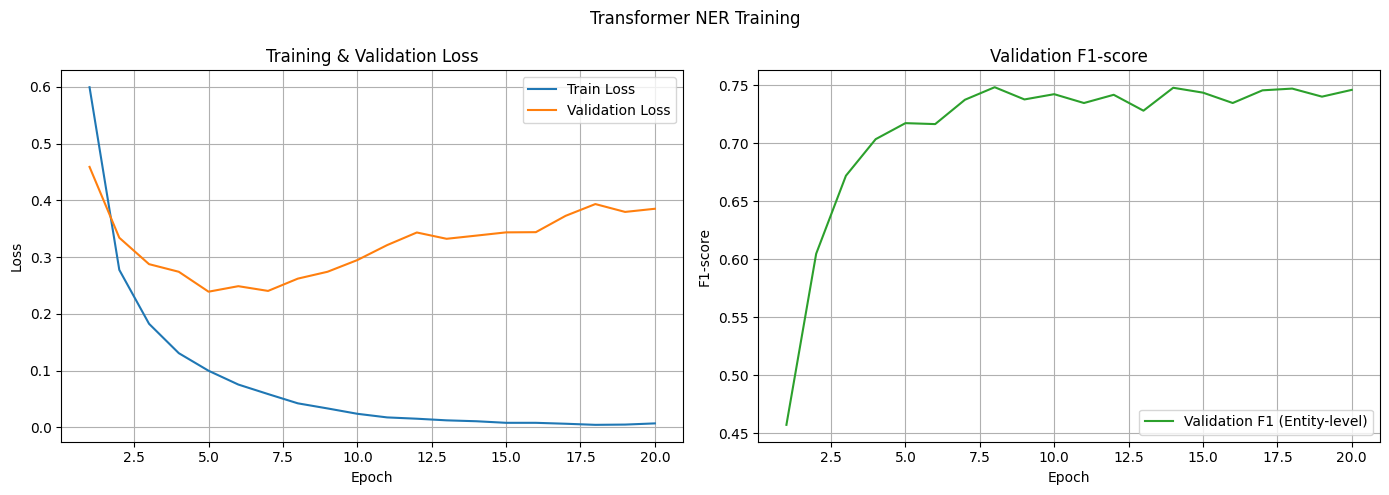

In [35]:
plot_ner_training_curves(
    trainer,
    title="Transformer NER Training"
)


## 6.7. Đánh giá cuối trên Test set

In [36]:
model.load_state_dict(torch.load("best_transformer_ner.pt"))
model.to(device)

test_f1, y_true, y_pred = evaluate_ner(
    model, test_loader, device
)

print("Test F1-score:", test_f1)
print("\nClassification report:")
print(classification_report(y_true, y_pred))

Test F1-score: 0.74227717588304

Classification report:
                     precision    recall  f1-score   support

                AGE       0.81      0.88      0.84       581
               DATE       0.76      0.90      0.82      1652
             GENDER       0.86      0.95      0.90       461
                JOB       0.36      0.39      0.38       173
           LOCATION       0.66      0.79      0.72      4437
               NAME       0.81      0.43      0.56       318
       ORGANIZATION       0.50      0.61      0.55       771
         PATIENT_ID       0.87      0.85      0.86      2002
SYMPTOM_AND_DISEASE       0.61      0.71      0.66      1136
     TRANSPORTATION       0.66      0.56      0.61       193

          micro avg       0.70      0.79      0.74     11724
          macro avg       0.69      0.71      0.69     11724
       weighted avg       0.71      0.79      0.74     11724



> Kết quả khá kém dù mô hình là transfomer, một kiến trúc 5 lớp Bi-LSTM với hidden state 256 cho kết quả F1_macro = 0.766

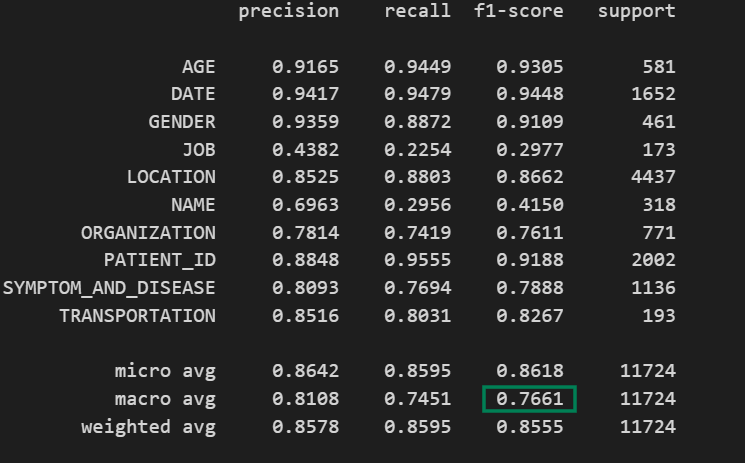

## 6.8 Nhận xét so sánh Transformer Encoder và Bi-LSTM cho bài toán NER

Từ kết quả thực nghiệm, ta thấy rằng Transformer Encoder thuần có phần kém hơn so với Bi-LSTM nhiều lớp khi đánh giá trên tập test. Tuy nhiên, là với một số nhãn mà Bi-LSTM có kết quả thấp - ví dụ như *JOB* hay *NAME* - thì Transformer Encoder lại cho kết quả tốt hơn hẳn. `F1: JOB 0.3 => 0.38 | Name 0.42 => 0.56`

Có vẻ như cơ chế self-attention đã giúp mô hình này nắm bắt được những mối liên hệ xa trong ngữ cảnh, đặc biệt là với những thực thể có cấu trúc phức tạp hoặc ít gặp trong dữ liệu.

Mặt khác, ở những nhãn mà Bi-LSTM vốn đã làm rất tốt rồi - như *LOCATION*, *ORGANIZATION* hay *PATIENT_ID* - thì Transformer Encoder lại kém hơn về kết quả. Nguyên nhân chính có thể là do Transformer Encoder only trong bài này này không có cơ chế để ràng buộc mối quan hệ giữa các nhãn liên tiếp nhau.

Việc dự đoán nhãn cho mỗi token một cách độc lập khiến mô hình dễ "lỗi" cấu trúc B-I (Begin, Inside), nhất là với các chuỗi thực thể dài, khi mà việc giữ đúng thứ tự *B* rồi mới tới *I* là rất quan trọng.

Nói chung, mặc dù Transformer Encoder có ưu điểm trong việc biểu diễn ngữ cảnh, nhưng việc thiếu đi khả năng mô hình hóa quan hệ tuần tự giữa các nhãn đã làm giảm hiệu quả của nó trong bài toán NER so với Bi-LSTM.

Có thể cải thiện bằng cách thêm cơ chế ràng buộc nhãn thực thể

# 7. Label Smoothing Loss cho NER (token-level)

## 7.1 Định nghĩa hàm loss smooth labeling

In [37]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, num_classes, smoothing=0.1, ignore_index=-100):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.ignore_index = ignore_index

    def forward(self, logits, target):
        """
        logits: [N, C]
        target: [N]
        """
        # Mask padding
        valid_mask = target != self.ignore_index
        logits = logits[valid_mask]
        target = target[valid_mask]

        if target.numel() == 0:
            return torch.tensor(0.0, device=logits.device)

        log_probs = torch.log_softmax(logits, dim=-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

In [38]:
criterion_ls = LabelSmoothingLoss(
    num_classes=NUM_CLASSES,
    smoothing=0.05
)

## 7.2 Huấn luyện mô hình

In [39]:
criterion_ls = LabelSmoothingLoss(
    num_classes=NUM_CLASSES,
    smoothing=0.05
)

model_ls = TransformerForNER(
    vocab_size=len(word2idx),
    max_len=MAX_LEN,
    d_model=256,
    num_heads=8,
    num_layers=3,
    d_ff=1024,
    num_tags=NUM_CLASSES,
    dropout=0.1
).to(device)

optimizer_ls = torch.optim.AdamW(
    model_ls.parameters(),
    lr=2e-4,
    weight_decay=1e-2
)

trainer_ls = TrainerNER(
    model=model_ls,
    optimizer=optimizer_ls,
    criterion=criterion_ls,
    device=device,
    train_loader=train_loader,
    val_loader=dev_loader,
    save_path="ner_ls_best.pt"
)

trainer_ls.fit(epochs=20)

Epoch 01 | Train Loss: 0.8598 | Val Loss: 0.7661 | Val F1: 0.4288
→ Saved best model
Epoch 02 | Train Loss: 0.5945 | Val Loss: 0.6503 | Val F1: 0.5891
→ Saved best model
Epoch 03 | Train Loss: 0.5149 | Val Loss: 0.6043 | Val F1: 0.6514
→ Saved best model
Epoch 04 | Train Loss: 0.4721 | Val Loss: 0.5851 | Val F1: 0.6904
→ Saved best model
Epoch 05 | Train Loss: 0.4440 | Val Loss: 0.5792 | Val F1: 0.7089
→ Saved best model
Epoch 06 | Train Loss: 0.4230 | Val Loss: 0.5947 | Val F1: 0.7085
Epoch 07 | Train Loss: 0.4049 | Val Loss: 0.5850 | Val F1: 0.7182
→ Saved best model
Epoch 08 | Train Loss: 0.3947 | Val Loss: 0.5788 | Val F1: 0.7304
→ Saved best model
Epoch 09 | Train Loss: 0.3833 | Val Loss: 0.6015 | Val F1: 0.7158
Epoch 10 | Train Loss: 0.3763 | Val Loss: 0.5920 | Val F1: 0.7337
→ Saved best model
Epoch 11 | Train Loss: 0.3709 | Val Loss: 0.5965 | Val F1: 0.7445
→ Saved best model
Epoch 12 | Train Loss: 0.3666 | Val Loss: 0.6030 | Val F1: 0.7407
Epoch 13 | Train Loss: 0.3653 | Val L

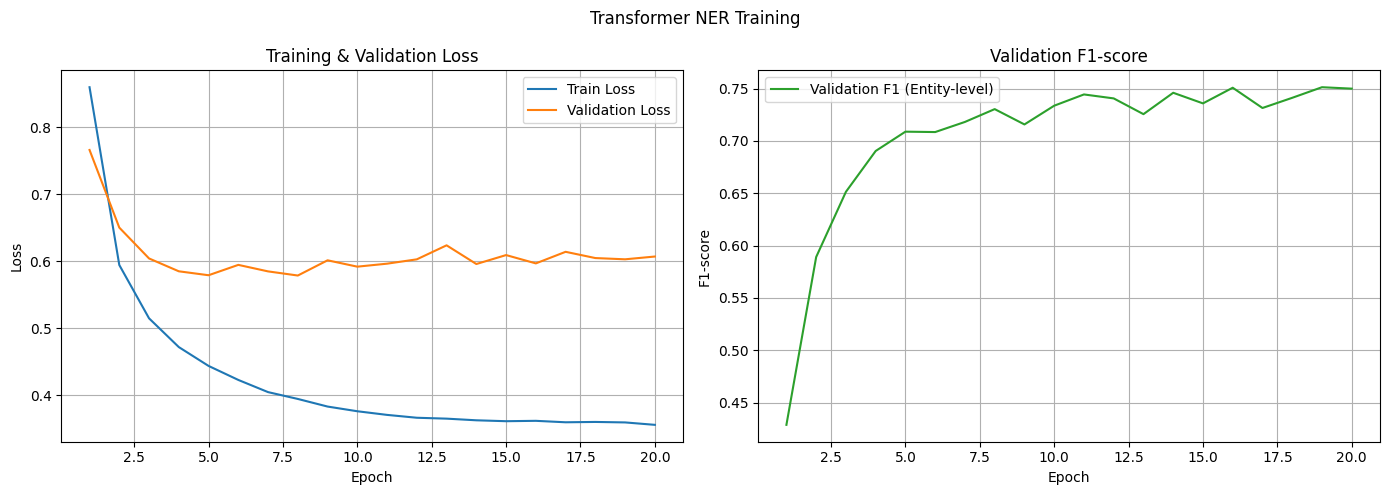

In [42]:
plot_ner_training_curves(
    trainer_ls,
    title="Transformer NER Training"
)


## 7. Đánh giá cuối trên Test set

In [43]:
model.load_state_dict(torch.load("ner_ls_best.pt"))
model.to(device)

test_f1, y_true, y_pred = evaluate_ner(
    model, test_loader, device
)

print("Test F1-score:", test_f1)
print("\nClassification report:")
print(classification_report(y_true, y_pred))

Test F1-score: 0.7374343900902792

Classification report:
                     precision    recall  f1-score   support

                AGE       0.80      0.87      0.83       581
               DATE       0.81      0.89      0.85      1652
             GENDER       0.91      0.94      0.92       461
                JOB       0.54      0.39      0.45       173
           LOCATION       0.67      0.72      0.69      4437
               NAME       0.85      0.44      0.58       318
       ORGANIZATION       0.51      0.62      0.56       771
         PATIENT_ID       0.89      0.83      0.86      2002
SYMPTOM_AND_DISEASE       0.61      0.65      0.63      1136
     TRANSPORTATION       0.79      0.55      0.65       193

          micro avg       0.73      0.75      0.74     11724
          macro avg       0.74      0.69      0.70     11724
       weighted avg       0.73      0.75      0.74     11724



So sánh hai hàm mất mát cho mô hình Transformer Encoder, kết quả cho thấy Cross Entropy đạt F1 macro thấp hơn một chút so với Label Smoothing (0.69 so với 0.70 của Label Smoothing trên tập test).

Mặc dù Label Smoothing giúp cải thiện độ chính xác ở một số nhãn hiếm `F1: JOB tăng từ 0.38 => 0.45, Name 0.56 => 0.58` và làm cho mô hình bớt over-confident, hiệu quả này chưa đủ để nâng cao đáng kể F1 macro tổng thể.

Điều này cho thấy trong bối cảnh bài toán NER và kiến trúc Transformer encoder thuần, việc làm “mềm” phân phối nhãn có thể làm suy yếu khả năng phân biệt ranh giới thực thể, đặc biệt đối với các nhãn yêu cầu tuân thủ chặt chẽ cấu trúc BIO, từ đó hạn chế lợi ích của Label Smoothing ở mức độ toàn cục.


# 8. In log

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def plot_experiment_comparison(
    trainer_a,
    trainer_b,
    name_a="Experiment A",
    name_b="Experiment B",
    title="Experiment Comparison"
):
    epochs_a = np.arange(1, len(trainer_a.val_losses) + 1)
    epochs_b = np.arange(1, len(trainer_b.val_losses) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ===============================
    # Plot 1: Validation Loss
    # ===============================
    axes[0].plot(epochs_a, trainer_a.val_losses, label=f"{name_a} - Val Loss")
    axes[0].plot(epochs_b, trainer_b.val_losses, label=f"{name_b} - Val Loss")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Validation Loss Comparison")
    axes[0].legend()
    axes[0].grid(True)

    # ===============================
    # Plot 2: Validation F1 (Macro)
    # ===============================
    axes[1].plot(epochs_a, trainer_a.val_f1s, label=f"{name_a} - F1 (Macro)")
    axes[1].plot(epochs_b, trainer_b.val_f1s, label=f"{name_b} - F1 (Macro)")

    # Mark best epoch for each experiment
    best_a = np.argmax(trainer_a.val_f1s)
    best_b = np.argmax(trainer_b.val_f1s)

    axes[1].scatter(
        epochs_a[best_a],
        trainer_a.val_f1s[best_a],
        marker="o"
    )
    axes[1].scatter(
        epochs_b[best_b],
        trainer_b.val_f1s[best_b],
        marker="o"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1-score")
    axes[1].set_title("Validation Macro F1-score Comparison")
    axes[1].legend()
    axes[1].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

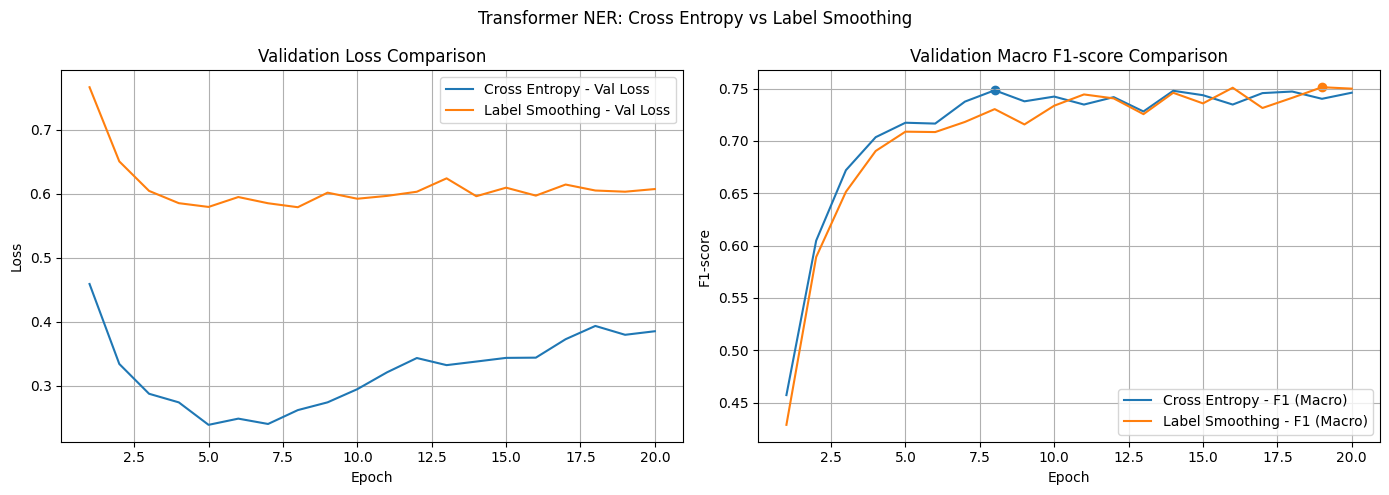

In [46]:
plot_experiment_comparison(
    trainer,
    trainer_ls,
    name_a="Cross Entropy",
    name_b="Label Smoothing",
    title="Transformer NER: Cross Entropy vs Label Smoothing"
)


> Có thể thấy loss không có tương quan mạnh lắm với F1, trong ảnh dù loss của smooth labeling loss cao, nhưng vẫn cho F1 macro kha khá